# Direct Preference Optimization (DPO) — Hands-On Tutorial

Welcome! This notebook teaches you **DPO (Direct Preference Optimization)**, one of the
most popular *post-training* / alignment techniques used to turn a plain instruction-tuned
model into one that better matches human preferences (more helpful, more concise, safer, etc.).

### What we'll do, step by step
1. Understand **what DPO is** and why it replaced the older RLHF + PPO pipeline for many use cases.
2. Load a **preference dataset** (pairs of "chosen" vs "rejected" responses).
3. Load **`Qwen/Qwen2.5-0.5B-Instruct`** — a small model that has *already* been through
   pretraining + supervised fine-tuning (SFT). DPO is the *next* stage after SFT.
4. Fine-tune it with **LoRA + DPO** using Hugging Face's `trl` library.
5. Compare the model's outputs **before vs. after** DPO training.

### Requirements
- **Runtime → Change runtime type → T4 GPU** (or any GPU) in Colab. This notebook is written
  to auto-detect whatever GPU you get (T4, L4, A100, ...) and adjust precision automatically.
  Expect roughly **30–90 minutes** for the default ~10k-pair / 2-epoch DPO run on a T4/L4.
- No Hugging Face login is required — both the model and the dataset we use are public.

> 💡 Every single cell below has a Markdown explanation above it. Read them in order — this
> notebook is meant to be read top-to-bottom like a mini-course, not just executed blindly.

## 1. What is DPO, really?

Before DPO, the standard way to align a language model with human preferences was **RLHF**:

1. Collect human preference data: for a prompt, show two model answers, ask a human which is better.
2. Train a separate **reward model** to predict "how much a human would like this answer".
3. Use **PPO** (a reinforcement-learning algorithm) to fine-tune the language model to maximize
   the reward model's score.

This works, but it's complex: you need to train *two* models (reward model + policy), RL training
is unstable and hyperparameter-sensitive, and you need to keep several models in memory/sampling loops
at once.

**DPO (Rafailov et al., 2023 — [paper](https://huggingface.co/papers/2305.18290))** shows a clever
mathematical trick: you can skip the reward model and the RL loop entirely. Instead, you can directly
optimize the language model on preference pairs `(prompt, chosen_response, rejected_response)` with a
**simple classification-style loss**. It provably optimizes the *same* objective as RLHF, but with a
single model, single training loop, and much more stability.

### The DPO loss (intuition first, math second)

Intuitively, DPO says: *"Increase the probability the model assigns to the chosen response, and
decrease the probability it assigns to the rejected response — but don't let the model drift too far
from where it started (the reference model), otherwise it will degenerate into gibberish or reward-hack."*

The "don't drift too far" part is enforced by comparing the fine-tuned model (called the **policy**,
$\pi_\theta$) against a **frozen reference model** ($\pi_{ref}$) — which is just a copy of the model
*before* DPO training (i.e., our SFT model, before we touch it).

Formally, for a preference pair $(x, y_w, y_l)$ where $y_w$ ("w" = winner) is the chosen response and
$y_l$ ("l" = loser) is the rejected response:

$$
\mathcal{L}_{DPO}(\pi_\theta; \pi_{ref}) = -\mathbb{E}_{(x, y_w, y_l)}\left[
\log \sigma\Big(
\beta \log\frac{\pi_\theta(y_w \mid x)}{\pi_{ref}(y_w \mid x)}
-
\beta \log\frac{\pi_\theta(y_l \mid x)}{\pi_{ref}(y_l \mid x)}
\Big)
\right]
$$

Where:
- $\sigma$ is the sigmoid function (turns the score difference into a 0-1 "probability that chosen > rejected").
- $\beta$ is a temperature-like hyperparameter: **higher $\beta$ = stay closer to the reference model**
  (more conservative), **lower $\beta$ = allowed to move further away** (more aggressive).
- Everything on the right is computed from **log-probabilities the model already gives you** — no
  extra reward model, no sampling/rollouts, no RL. Just a forward pass on the two candidate answers
  and a loss you can backprop through directly, exactly like a normal cross-entropy fine-tune.

### Why start from an *SFT* model?
DPO assumes the starting model already knows how to follow instructions reasonably well — its job is
to *re-rank* / *sharpen* the model's existing behavior towards what humans prefer, not to teach it
new capabilities from scratch. That's exactly why we use `Qwen/Qwen2.5-0.5B-Instruct`: the
`-Instruct` suffix means Qwen already SFT'd it. We are simply running the **next stage** of the
typical post-training pipeline: **Pretraining → SFT → Preference Optimization (DPO)**.

## 2. Check your GPU

Colab gives you a random GPU (usually a **T4**, sometimes an **L4** or **A100** if you have Colab
Pro). Run the cell below to see what you got — you don't need to change anything, later cells will
automatically detect the GPU type and pick the right settings (e.g., T4 doesn't support `bfloat16`
efficiently, but L4/A100 do).

In [1]:
!nvidia-smi

Fri Sep 18 08:31:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   37C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 3. Install libraries

We need:
- **`transformers`** — loads the Qwen model + tokenizer.
- **`trl`** (Transformer Reinforcement Learning) — provides the ready-made `DPOTrainer` and
  `DPOConfig` classes so we don't have to implement the DPO loss by hand.
- **`peft`** (Parameter-Efficient Fine-Tuning) — lets us train with **LoRA** instead of updating
  every single weight, which is much faster and uses far less GPU memory.
- **`datasets`** — Hugging Face's library for loading the preference dataset.
- **`accelerate`** — handles moving tensors/model to the GPU efficiently under the hood.

We use `-U` (upgrade) to make sure Colab's pre-installed versions are recent enough to have the
`DPOTrainer` API we use below.

In [2]:
!pip install -q -U transformers trl peft datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 38.8 MB/s eta 0:00:00


## 4. Imports and reproducibility

Standard imports, plus:
- `set_seed(...)` makes shuffling / sampling reproducible so you get similar results if you re-run
  this notebook.
- We hard-assert that a CUDA GPU is visible. If this fails, go to
  **Runtime → Change runtime type → T4 GPU** and re-run the notebook from the top.
- We also detect **whether your specific GPU supports `bfloat16`** efficiently. `bfloat16` (bf16) is
  a 16-bit float format with the same exponent range as 32-bit floats, so it's numerically safer than
  classic `float16` (fp16) for training — but it's only *natively* accelerated on NVIDIA Ampere-or-newer
  GPUs (A100, L4, RTX 30/40-series, ...). Older GPUs like the **T4** (Colab's free default) don't
  support it well, so we fall back to `fp16` automatically there.

In [3]:
import random
import numpy as np
import torch
from transformers import set_seed

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

assert torch.cuda.is_available(), (
    "No GPU found! Go to Runtime -> Change runtime type -> T4 GPU (or better), "
    "then Runtime -> Restart session, and re-run this notebook from the top."
)

DEVICE = torch.device("cuda")
GPU_NAME = torch.cuda.get_device_name(0)

# Ampere (A100, L4, RTX 30/40-series) and newer support bf16 efficiently.
# Older cards (e.g. Colab's free T4, which is Turing) do not, so we use fp16 there instead.
USE_BF16 = torch.cuda.is_bf16_supported()
TORCH_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16

print(f"GPU detected        : {GPU_NAME}")
print(f"Using bfloat16       : {USE_BF16}")
print(f"Training/model dtype : {TORCH_DTYPE}")

GPU detected        : NVIDIA A100-SXM4-80GB
Using bfloat16       : True
Training/model dtype : torch.bfloat16


## 5. The dataset: `trl-lib/ultrafeedback_binarized`

DPO needs **preference pairs**: for the same prompt, one response humans (or a strong judge model)
preferred (`chosen`) and one they didn't (`rejected`).

We use **[`trl-lib/ultrafeedback_binarized`](https://huggingface.co/datasets/trl-lib/ultrafeedback_binarized)**,
a cleaned, ready-to-use version of the popular **UltraFeedback** dataset, pre-formatted exactly the
way `trl`'s `DPOTrainer` expects. This is also the exact dataset used in TRL's own official DPO
example script together with a Qwen2 0.5B model, so it's a well-tested pairing for a small model like
ours.

Each row has three columns:
- **`prompt`** — a user message, e.g. `[{"role": "user", "content": "..."}]`
- **`chosen`** — the preferred assistant reply, e.g. `[{"role": "assistant", "content": "..."}]`
- **`rejected`** — a worse assistant reply, in the same format

This "list of role/content dicts" format is called the **conversational format**. The nice part:
`DPOTrainer` automatically detects this format and applies Qwen's own chat template to it for us —
we don't need to manually format anything.

In [4]:
from datasets import load_dataset

raw_dataset = load_dataset("trl-lib/ultrafeedback_binarized")
print(raw_dataset)

README.md:   0%|          | 0.00/643 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  131MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.14MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/62135 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 62135
    })
    test: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 1000
    })
})


### Dataset size for a meaningful DPO run

The full training split has ~62,000 examples. We use a **larger subset** than a tiny demo so the
preference signal is strong enough to move metrics (loss, reward margin, accuracy). On a T4/L4 this
may take ~30–90 minutes depending on GPU — still far less than the full dataset.

After the tokenizer is loaded, we also **filter out examples whose prompt alone exceeds
`MAX_PROMPT_TOKENS`**, so completions are not wiped out by truncation under `max_prompt_length` +
`max_completion_length`.

In [5]:
N_TRAIN = 10_000  # target size after length filtering
N_EVAL = 500
# Oversample candidates so we still reach N_TRAIN after dropping long prompts
CANDIDATE_TRAIN = 25_000
CANDIDATE_EVAL = 2_000
MAX_PROMPT_TOKENS = 512  # applied after tokenizer load (see model section)

train_dataset = raw_dataset["train"].shuffle(seed=SEED).select(
    range(min(CANDIDATE_TRAIN, len(raw_dataset["train"])))
)
eval_dataset = raw_dataset["test"].shuffle(seed=SEED).select(
    range(min(CANDIDATE_EVAL, len(raw_dataset["test"])))
)

print(f"Train candidates (pre-length filter): {len(train_dataset)}")
print(f"Eval candidates  (pre-length filter): {len(eval_dataset)}")

Train candidates (pre-length filter): 25000
Eval candidates  (pre-length filter): 1000


### Peeking at one example

Let's print a single row so you can see exactly what the model will be trained on: one shared prompt,
and two candidate continuations of it — one good, one bad.

In [6]:
example = train_dataset[0]

# The prompt is typically the content of the first message (from the user)
# in the conversational lists.
print("PROMPT:")
print(example["chosen"][0]["content"])

print("\nCHOSEN (preferred) response:")
print(example["chosen"][1]["content"] if len(example["chosen"]) > 1 else example["chosen"])

print("\nREJECTED (worse) response:")
print(example["rejected"][1]["content"] if len(example["rejected"]) > 1 else example["rejected"])

PROMPT:
INPUT ARTICLE: Article: Different laptop models have different numeric pad configurations.  If your U, I, and O keys have 4, 5, and 6 printed in the lower corner, you have an older laptop with an alternate numeric pad. See the next section for details on using it. The ThinkPad line of laptops do not use an alternate numeric pad. You'll need to use the method in this section as a workaround. Some larger models have a dedicated numeric pad. Click the "Start" button in the lower-right corner of the desktop. In many versions of Windows, this is just a Windows icon. The Start menu will appear above the button. If you are using Windows 8 and don't see the Start button, press ⊞ Win on the keyboard. This will open the Start screen. You can start typing immediately when the Start menu or screen is open to begin searching. You'll see "On-Screen Keyboard" in the search results. If your Lenovo laptop does not have a NumLock key, you can use the Windows On-Screen Keyboard to access the nume

## 6. Load the base model: `Qwen/Qwen2.5-0.5B-Instruct`

This is a **0.5-billion parameter** chat model from the Qwen2.5 family. The `-Instruct` suffix
means Alibaba already ran pretraining + SFT on it, so it already knows how to follow instructions and
chat — DPO will *refine* that behavior rather than teach it from zero.

A few details worth understanding:
- We load the model in `TORCH_DTYPE` (bf16 or fp16, decided above) instead of the default 32-bit
  floats — this cuts memory usage roughly in half with a negligible quality difference for
  inference/fine-tuning.
- `device_map="cuda"` places the model directly on the GPU.
- We make sure the tokenizer has a `pad_token`. Many chat models don't ship with one because they're
  normally used for one-sequence-at-a-time generation, but training needs to batch multiple sequences
  together, which requires padding shorter ones. We reuse the end-of-sequence token for this, which is
  a very common convention.
- We set `padding_side="left"` for chat generation (standard for decoder-only models). `DPOTrainer`
  manages padding for the training batches itself.
- We filter the train/eval sets so prompts fit in `MAX_PROMPT_TOKENS`, leaving room for completions.

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=TORCH_DTYPE,
    device_map="cuda",
)
# Needed when gradient checkpointing + LoRA are both enabled later.
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()


def prompt_fits_length(example, max_prompt_tokens=MAX_PROMPT_TOKENS):
    """Keep pairs whose user prompt fits, so completions are not fully truncated."""
    prompt_messages = example["chosen"][:-1]
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return len(tokenizer.encode(prompt_text, add_special_tokens=False)) <= max_prompt_tokens


train_dataset = train_dataset.filter(prompt_fits_length)
eval_dataset = eval_dataset.filter(prompt_fits_length)
train_dataset = train_dataset.select(range(min(N_TRAIN, len(train_dataset))))
eval_dataset = eval_dataset.select(range(min(N_EVAL, len(eval_dataset))))

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded {MODEL_ID}")
print(f"Total parameters: {n_params:,}")
print(f"Train examples (post-length filter): {len(train_dataset)}")
print(f"Eval examples  (post-length filter): {len(eval_dataset)}")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loaded Qwen/Qwen2.5-0.5B-Instruct
Total parameters: 494,032,768
Train examples (post-length filter): 10000
Eval examples  (post-length filter): 500


## 7. Baseline: see what the model says *before* DPO

Before we change anything, let's capture the model's current behavior on a few prompts. We'll ask the
same questions again *after* training, so we can directly compare "before" vs "after".

Notice we use `tokenizer.apply_chat_template(...)`. This wraps our plain text into whatever special
chat-formatting tokens Qwen was trained to expect (e.g. `<|im_start|>user ... <|im_end|>`), so the
model treats it as a real chat turn instead of raw, unstructured text.

Generation uses **greedy decoding** (`do_sample=False`) so before/after differences come from the
weights, not from sampling noise.

In [8]:
TEST_PROMPTS = [
    "What's the best way to learn a new language as an adult?",
    "Write a short, polite email declining a meeting invitation.",
    "Explain what a black hole is to a 10 year old.",
]

@torch.no_grad()
def generate_response(model, tokenizer, user_prompt, max_new_tokens=200):
    '''Formats `user_prompt` as a chat turn, runs greedy generation, and returns only the new text.'''
    messages = [{"role": "user", "content": user_prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # deterministic: fair before/after comparison
        pad_token_id=tokenizer.pad_token_id,
    )

    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


print("Generating baseline (pre-DPO) responses... this takes ~10-20 seconds.\n")
baseline_responses = {}
for prompt in TEST_PROMPTS:
    response = generate_response(model, tokenizer, prompt)
    baseline_responses[prompt] = response
    print(f"PROMPT: {prompt}")
    print(f"BEFORE DPO: {response}")
    print("-" * 80)

Generating baseline (pre-DPO) responses... this takes ~10-20 seconds.

PROMPT: What's the best way to learn a new language as an adult?
BEFORE DPO: Learning a new language can be both challenging and rewarding, especially for adults who may not have had formal education in that area before. Here are some tips on how to effectively learn a new language:

1. **Set Clear Goals**: Define what you want to achieve with your language learning. Whether it’s improving your vocabulary, grammar skills, or fluency, having specific goals will help guide your progress.

2. **Start Small**: Begin with simple phrases and gradually work up to more complex sentences and conversations. This approach helps prevent burnout and keeps your interest high.

3. **Use Multiple Resources**: Don’t limit yourself to just one source of information. Use books, online courses, apps, and even podcasts to supplement your learning. The more resources you use, the better you’ll understand the language.

4. **Practice Regu

## 8. Parameter-efficient fine-tuning with LoRA

Instead of updating all ~500 million parameters of the model, we use **LoRA (Low-Rank Adaptation)**.
The idea: freeze the original weights, and next to certain layers, inject a pair of tiny trainable
matrices whose product approximates the *change* the fine-tune wants to make. This means:

- **Far fewer trainable parameters** (often <1% of the full model) → much less GPU memory, faster training.
- **The original weights never change**, so you can keep multiple "LoRA adapters" for different tasks
  and swap them in and out of the same base model.
- **A nice side benefit for DPO specifically**: DPO needs a frozen *reference* copy of the model to
  compare against. When you use LoRA, `trl` doesn't need to keep a whole second copy of the model in
  memory for this — it simply computes the reference log-probabilities with the LoRA adapter
  **disabled** (i.e., using the untouched base weights). That's a big memory saving on a free Colab GPU.

Key LoRA hyperparameters:
- **`r`** (rank): the size of the injected matrices. Higher `r` = more capacity to learn, but more
  parameters. We use `r=32` here for a stronger preference shift on this data size (8–32 is typical).
- **`lora_alpha`**: a scaling factor for the LoRA update (roughly, "how strongly the adapter's output
  is applied"). A common rule of thumb is `lora_alpha = 2 * r`.
- **`lora_dropout`**: regular dropout applied inside the adapter, to reduce overfitting.
- **`target_modules`**: *which* weight matrices inside each transformer block get a LoRA adapter. For
  Qwen2/Qwen2.5's architecture, the attention projections (`q_proj`, `k_proj`, `v_proj`, `o_proj`) and
  the MLP projections (`gate_proj`, `up_proj`, `down_proj`) are the standard choice.

In [9]:
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=32,                # higher rank for a stronger preference shift on this data size
    lora_alpha=64,       # keep alpha = 2 * r
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",   # attention block
        "gate_proj", "up_proj", "down_proj",      # MLP block
    ],
)

print(lora_config)

LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.21.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=32, target_modules={'gate_proj', 'o_proj', 'q_proj', 'k_proj', 'down_proj', 'v_proj', 'up_proj'}, exclude_modules=None, lora_alpha=64, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, kasa_config=

### (Optional) Sanity check: how many parameters will actually be trained?

This cell temporarily wraps the model with the LoRA adapter just to print the trainable-parameter
count, then **unwraps it again** (`.unload()`) so we can hand a clean base model to the trainer below
— `DPOTrainer` will apply `lora_config` itself and would raise an error if we gave it a model that was
already wrapped.

In [10]:
import peft.import_utils
import peft.tuners.lora.torchao
from peft import get_peft_model

# Override PEFT's torchao checks across all internal modules to bypass the version error
peft.import_utils.is_torchao_available = lambda: False
peft.tuners.lora.torchao.is_torchao_available = lambda: False

_preview = get_peft_model(model, lora_config)
_preview.print_trainable_parameters()
model = _preview.unload()  # strips the adapter back off, `model` is a clean base model again

trainable params: 17,596,416 || all params: 511,629,184 || trainable%: 3.4393


## 9. Configure DPO training (`DPOConfig`)

`DPOConfig` is `trl`'s training-configuration class — it's a superset of the familiar
`transformers.TrainingArguments`, plus a few DPO-specific settings. Here's what each argument below
does:

**General training arguments** (same as any Hugging Face `Trainer`):
- `per_device_train_batch_size` / `gradient_accumulation_steps` — here `4 × 8 = 32` effective batch
  size, which stabilizes DPO gradients versus a tiny batch.
- `num_train_epochs` — two passes over the filtered subset so margins have time to rise.
- `learning_rate` — `1e-5` for LoRA-DPO (higher than a weak `5e-6` demo LR, still below typical SFT).
- `warmup_steps` / `lr_scheduler_type` — cosine schedule with a short warmup (~10% of a ~500–600 step run).
- `gradient_checkpointing` — trades a bit of speed for memory headroom at longer sequences.
- `eval_strategy` / `save_strategy` / `load_best_model_at_end` — evaluate periodically, keep the
  checkpoint with the best eval reward margin (not just the last step).
- `report_to="none"` — disable third-party experiment trackers inside Colab.

**DPO-specific arguments**:
- `beta` — `0.1` (standard default).
- `max_length` — max prompt+completion tokens (`512 + 512 = 1024`). Prompts were pre-filtered to
  `MAX_PROMPT_TOKENS`, so completions keep room under this cap instead of being wiped by truncation.
- `loss_type="sigmoid"` — classic DPO; swap to `"ipo"` later if you want a more overfit-resistant loss.

In [11]:
from trl import DPOConfig

training_args = DPOConfig(
    output_dir="./qwen2.5-0.5b-dpo",
    # --- batching / schedule ---
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,  # effective batch = 32
    num_train_epochs=2,
    learning_rate=1e-5,
    lr_scheduler_type="cosine",
    warmup_steps=50,  # ~10% of ~500–600 optimizer steps on this setup
    # --- memory / precision ---
    gradient_checkpointing=True,
    bf16=USE_BF16,
    fp16=not USE_BF16,
    # --- logging / evaluation / checkpoints ---
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_rewards/margins",
    greater_is_better=True,
    report_to="none",
    remove_unused_columns=False,
    # --- DPO-specific ---
    beta=0.1,
    loss_type="sigmoid",
    # Prompts are pre-filtered to MAX_PROMPT_TOKENS so completions retain budget.
    max_length=MAX_PROMPT_TOKENS + 512,
    seed=SEED,
)

## 10. Build the `DPOTrainer`

This is the core object that does all the heavy lifting: dataset tokenization + chat-template
formatting, computing the DPO loss, running the optimizer, logging metrics, and (thanks to
`peft_config`) wrapping our model with the LoRA adapter we defined above.

A couple of arguments worth calling out:
- `ref_model=None` — normally, `DPOTrainer` would clone your model into a second, frozen copy to use
  as $\pi_{ref}$. But since we passed `peft_config`, it's smart enough to skip that: it will instead
  compute reference log-probabilities by temporarily *disabling* the LoRA adapter (falling back to the
  frozen base weights) and re-enabling it afterwards. Net effect: one model in memory, not two.
- `processing_class=tokenizer` — this is the modern `trl`/`transformers` name for what used to be
  called `tokenizer=`. It's used both to tokenize text and to apply Qwen's chat template to the
  conversational `prompt` / `chosen` / `rejected` columns automatically.

In [12]:
from trl import DPOTrainer

trainer = DPOTrainer(
    model=model,
    ref_model=None,                 # None + peft_config => reference computed via adapter-disable trick
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    peft_config=lora_config,
)

Extracting prompt from train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dropping fully truncated examples from train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Extracting prompt from eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Dropping fully truncated examples from eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

## 11. Train!

With ~10k filtered pairs, 2 epochs, and effective batch 32, expect on the order of **~30–90 minutes**
on a T4/L4 (not the old 5–15 minute toy run). The trainer will also keep the **best checkpoint by
eval reward margin** via `load_best_model_at_end`.

**What to watch in the logs while it runs:**
- **`loss`** — should generally trend down from ~0.69 (`ln 2`).
- **`rewards/chosen`** and **`rewards/rejected`** — these are *not* real-world rewards; they're the
  $\beta \cdot \log\frac{\pi_\theta}{\pi_{ref}}$ terms from the loss formula. Watch them *diverge*.
- **`rewards/margins`** — should trend **upward**.
- **`rewards/accuracies`** — should climb from ~0.5 toward **0.6–0.8+**. If it stays near 0.55, the
  run is still under-powered.

In [13]:
train_result = trainer.train()

print("\nBest checkpoint loaded (by eval reward margin). Final train metrics:")
print(train_result.metrics)

eval_metrics = trainer.evaluate()
print("\nHeld-out eval metrics:")
for k, v in eval_metrics.items():
    print(f"  {k}: {v}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
50,0.655772,0.663938,1.300886,1265421.000000,-2.031920,-2.042402,0.665627,-0.169913,-0.277495,0.600000,0.107583,-373.572982,-320.175860
100,0.620059,0.633077,1.280002,2552570.000000,-2.076674,-2.093563,0.665346,-0.193333,-0.426521,0.634000,0.233189,-373.807186,-321.666121
150,0.621521,0.627331,1.302571,3809972.000000,-2.048938,-2.063522,0.664566,-0.284342,-0.588878,0.638000,0.304536,-374.717272,-323.289686
200,0.610291,0.621953,1.282140,5073979.000000,-2.105151,-2.127190,0.665152,-0.229125,-0.524153,0.644000,0.295028,-374.165103,-322.642433
250,0.579663,0.632560,1.279307,6350402.000000,-2.141475,-2.158443,0.662910,-0.453674,-0.828333,0.624000,0.374660,-376.410592,-325.684240
300,0.629649,0.612788,1.277553,7634475.000000,-2.119247,-2.142272,0.664845,-0.247331,-0.593477,0.640000,0.346146,-374.347164,-323.335674
350,0.469171,0.614181,1.271828,8922349.000000,-2.149566,-2.175126,0.664285,-0.356956,-0.725031,0.650000,0.368074,-375.443419,-324.651213
400,0.393518,0.619548,1.264045,10228411.000000,-2.179100,-2.209542,0.663894,-0.413390,-0.789847,0.642000,0.376457,-376.007750,-325.299374
450,0.420391,0.611793,1.257694,11517101.000000,-2.202925,-2.234449,0.663763,-0.454978,-0.853960,0.646000,0.398983,-376.423632,-325.940508
500,0.430632,0.608081,1.271545,12763297.000000,-2.156487,-2.184899,0.663356,-0.449641,-0.857515,0.642000,0.407874,-376.370266,-325.976053



Best checkpoint loaded (by eval reward margin). Final train metrics:
{'train_runtime': 3102.0782, 'train_samples_per_second': 6.447, 'train_steps_per_second': 0.202, 'total_flos': 6.618289317110784e+16, 'train_loss': 0.5273724047901531, 'epoch': 2.0}


Training Loss,Validation Loss,Step,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
0.437976,0.606500,626,1.268204,15922028.000000,-2.161937,-2.191630,0.663601,-0.437157,-0.852647,0.642000,0.415490,-376.245424,-325.927373



Held-out eval metrics:
  eval_loss: 0.6065003871917725
  eval_entropy: 1.2682043805122376
  eval_num_tokens: 15922028.0
  eval_logits/chosen: -2.161936586642336
  eval_logits/rejected: -2.1916299161949335
  eval_mean_token_accuracy: 0.6636009116172791
  eval_rewards/chosen: -0.4371569950580597
  eval_rewards/rejected: -0.8526466071605683
  eval_rewards/accuracies: 0.642
  eval_rewards/margins: 0.41548961359262465
  eval_logps/chosen: -376.2454242553711
  eval_logps/rejected: -325.9273734436035


## 12. Visualize the training curves

Let's pull the metrics `DPOTrainer` logged during training out of `trainer.state.log_history` and
plot them, so the trends described above are easy to see at a glance.

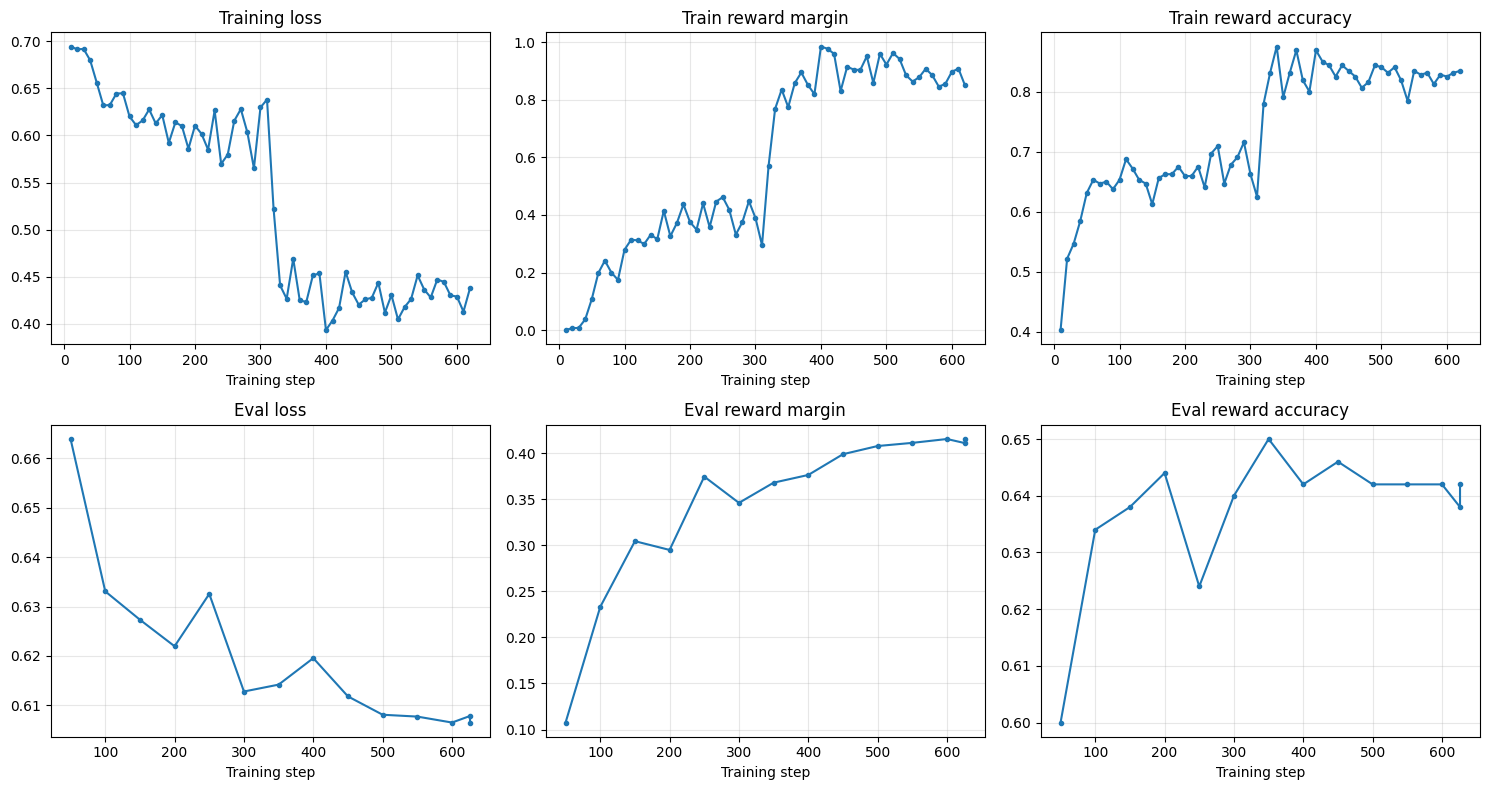

In [14]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

def extract(key):
    xs, ys = [], []
    for entry in history:
        if key in entry:
            xs.append(entry.get("step", entry.get("epoch")))
            ys.append(entry[key])
    return xs, ys

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, key, title in [
    (axes[0, 0], "loss", "Training loss"),
    (axes[0, 1], "rewards/margins", "Train reward margin"),
    (axes[0, 2], "rewards/accuracies", "Train reward accuracy"),
    (axes[1, 0], "eval_loss", "Eval loss"),
    (axes[1, 1], "eval_rewards/margins", "Eval reward margin"),
    (axes[1, 2], "eval_rewards/accuracies", "Eval reward accuracy"),
]:
    xs, ys = extract(key)
    if xs:
        ax.plot(xs, ys, marker="o", markersize=3)
    else:
        ax.text(0.5, 0.5, "no logged points", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("Training step")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Save the fine-tuned model

`trainer.save_model(...)` saves the **LoRA adapter weights** (a small file, typically just a few MB
for a model this size) plus the config needed to reload them on top of the original base model. We
also save the tokenizer alongside it, which is good practice so the two always travel together.

In [15]:
SAVE_DIR = "./qwen2.5-0.5b-dpo-adapter"

# Saves the best LoRA adapter (load_best_model_at_end already restored it on trainer.model).
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Saved best LoRA adapter + tokenizer to: {SAVE_DIR}")
if getattr(trainer.state, "best_model_checkpoint", None):
    print(f"Best checkpoint was: {trainer.state.best_model_checkpoint}")
    print(f"Best metric ({training_args.metric_for_best_model}): {trainer.state.best_metric}")

Saved best LoRA adapter + tokenizer to: ./qwen2.5-0.5b-dpo-adapter
Best checkpoint was: ./qwen2.5-0.5b-dpo/checkpoint-600
Best metric (eval_rewards/margins): 0.41548961359262465


## 14. Compare: before vs. after DPO

Ask the model the **exact same prompts** from Section 7 again. Generation is greedy, so differences
are from the LoRA weights — not sampling noise. `trainer.model` already has the best adapter active.

In [16]:
print("Generating post-DPO responses...\n")

for prompt in TEST_PROMPTS:
    after_response = generate_response(trainer.model, tokenizer, prompt)
    print(f"PROMPT: {prompt}")
    print(f"\n  BEFORE DPO:\n  {baseline_responses[prompt]}")
    print(f"\n  AFTER DPO:\n  {after_response}")
    print("=" * 100)

Generating post-DPO responses...

PROMPT: What's the best way to learn a new language as an adult?

  BEFORE DPO:
  Learning a new language can be both challenging and rewarding, especially for adults who may not have had formal education in that area before. Here are some tips on how to effectively learn a new language:

1. **Set Clear Goals**: Define what you want to achieve with your language learning. Whether it’s improving your vocabulary, grammar skills, or fluency, having specific goals will help guide your progress.

2. **Start Small**: Begin with simple phrases and gradually work up to more complex sentences and conversations. This approach helps prevent burnout and keeps your interest high.

3. **Use Multiple Resources**: Don’t limit yourself to just one source of information. Use books, online courses, apps, and even podcasts to supplement your learning. The more resources you use, the better you’ll understand the language.

4. **Practice Regularly**: Consistency is key when

## 15. Next steps & things to try

You've now run a full DPO fine-tuning loop end-to-end. Further ideas:

- **Full dataset**: remove the `.select(range(N_TRAIN))` subsetting (or set `N_TRAIN` to the full
  ~62k) for a stronger production-style run.
- **Different `beta`**: lower (e.g. `0.05`) for a bigger behavior shift, or raise (e.g. `0.3`) to stay
  closer to the SFT prior.
- **Other losses**: try `loss_type="ipo"` in `DPOConfig` if you want a more overfit-resistant objective.
- **Merge the adapter** for standalone deployment:

```python
merged_model = trainer.model.merge_and_unload()
merged_model.save_pretrained("./qwen2.5-0.5b-dpo-merged")
tokenizer.save_pretrained("./qwen2.5-0.5b-dpo-merged")
```

- **Push to the Hub**:

```python
# from huggingface_hub import login
# login()
# trainer.push_to_hub("your-username/qwen2.5-0.5b-dpo")
```

- **Stronger eval**: LLM-as-judge win rate on a fixed prompt set, beyond reward accuracy/margins.

### Further reading
- DPO paper: https://huggingface.co/papers/2305.18290
- `trl` DPOTrainer docs: https://huggingface.co/docs/trl/main/en/dpo_trainer
- UltraFeedback: https://huggingface.co/datasets/openbmb/UltraFeedback

In [17]:
merged_model = trainer.model.merge_and_unload()
merged_model.save_pretrained("./qwen2.5-0.5b-dpo-merged")
tokenizer.save_pretrained("./qwen2.5-0.5b-dpo-merged")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./qwen2.5-0.5b-dpo-merged/tokenizer_config.json',
 './qwen2.5-0.5b-dpo-merged/chat_template.jinja',
 './qwen2.5-0.5b-dpo-merged/tokenizer.json')

In [19]:
merged_model.push_to_hub("rautaditya/qwen2.5-0.5b-dpo")
tokenizer.push_to_hub("rautaditya/qwen2.5-0.5b-dpo")

README.md:   0%|          | 0.00/2.36k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...xkuuqai/model.safetensors:   3%|2         | 27.9MB /  988MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp31t2qtut/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/rautaditya/qwen2.5-0.5b-dpo/commit/1692f6365110d3f8bd8745d7cc58f83ffb168fe0', commit_message='Upload tokenizer', commit_description='', oid='1692f6365110d3f8bd8745d7cc58f83ffb168fe0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/rautaditya/qwen2.5-0.5b-dpo', endpoint='https://huggingface.co', repo_type='model', repo_id='rautaditya/qwen2.5-0.5b-dpo'), pr_revision=None, pr_num=None)

In [18]:
from huggingface_hub import login
login()  # paste a token from https://huggingface.co/settings/tokens
trainer.push_to_hub("rautaditya/qwen2.5-0.5b-dpo")

CommitInfo(commit_url='https://huggingface.co/rautaditya/qwen2.5-0.5b-dpo/commit/ce99ba492e2e47d2c9724b92e60035c9ba1b9c3d', commit_message='rautaditya/qwen2.5-0.5b-dpo', commit_description='', oid='ce99ba492e2e47d2c9724b92e60035c9ba1b9c3d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/rautaditya/qwen2.5-0.5b-dpo', endpoint='https://huggingface.co', repo_type='model', repo_id='rautaditya/qwen2.5-0.5b-dpo'), pr_revision=None, pr_num=None)

In [20]:
from huggingface_hub import HfApi

api = HfApi()
repo_id = "rautaditya/qwen2.5-0.5b-dpo"

# 1. Delete conflicting adapter files from the remote repository
for adapter_file in ["adapter_config.json", "adapter_model.safetensors"]:
    try:
        api.delete_file(
            path_in_repo=adapter_file,
            repo_id=repo_id,
            repo_type="model"
        )
        print(f"Removed {adapter_file} from repository.")
    except Exception:
        pass

# 2. Upload the entire merged folder (model weights, config, tokenizer)
api.upload_folder(
    folder_path="./qwen2.5-0.5b-dpo-merged",
    repo_id=repo_id,
    repo_type="model",
    commit_message="Publish full standalone merged model"
)

print("Full standalone model upload complete!")

Removed adapter_config.json from repository.
Removed adapter_model.safetensors from repository.


No files have been modified since last commit. Skipping to prevent empty commit.


Full standalone model upload complete!


In [23]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

repo_id = "rautaditya/qwen2.5-0.5b-dpo"

# Loads full 0.5B standalone model
model = AutoModelForCausalLM.from_pretrained(
    repo_id,
    dtype=torch.bfloat16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(repo_id)

# Quick inference test
messages = [{"role": "user", "content": "What is the capital of France?"}]
inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt").to(model.device)

# Unpack the inputs dictionary with **inputs
outputs = model.generate(**inputs, max_new_tokens=50)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

The capital of France is Paris.

Paris is the largest and most populous city in France, located on the northern bank of the River Seine. It is known for its rich history, art, culture, cuisine, and fashion. The city's status
